# 02. Time-Series Demand Analysis & Stationarity Testing

**Project:** Fodripio - Forecast-Driven Production Planning and Inventory Optimization Under Uncertain Demand  
**Phase:** Phase 1 — Demand Data Understanding  

## Objectives
1. Characterize trend, seasonality, and stationarity (ADF & KPSS tests) for all SKUs (`P1`–`P5`).
2. Analyze autocorrelation (ACF/PACF) and inter-product demand correlation.
3. Quantify exogenous variables (price elasticity & promotional lift).
4. Verify leak-free feature engineering via `FeatureEngineer`.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# Ensure project root is in sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.data.load import DataLoader
from src.data.features import FeatureEngineer

plt.style.use('seaborn-v0_8-whitegrid')
print("Environment initialized.")

Environment initialized.


## 1. Load Processed Demand Data

In [2]:
data_path = os.path.join(project_root, 'data', 'processed', 'demand_processed.csv')
loader = DataLoader(data_path)
df = loader.load_raw_data()
print("Loaded dataset rows:", len(df))
df.head()

2026-09-18 09:18:04,760 - INFO - Loading raw demand data from C:\zendvalmics\project\fodripio\data\processed\demand_processed.csv
2026-09-18 09:18:04,776 - INFO - Loaded 3655 rows spanning 2024-01-01 00:00:00 to 2025-12-31 00:00:00


Loaded dataset rows: 3655


,date,product_id,demand,price,promotion,holiday,shock,is_outlier
0,2024-01-01,P1,59.28,100.78,0,1,0,False
1,2024-01-01,P2,68.33,127.06,0,1,0,False
2,2024-01-01,P3,122.09,149.01,0,1,0,False
3,2024-01-01,P4,49.24,171.94,0,1,0,False
4,2024-01-01,P5,18.16,202.66,0,1,0,False


## 2. Statistical Stationarity Testing (ADF & KPSS Tests)

In [3]:
products = sorted(df['product_id'].unique())
test_results = []

for p_id in products:
    p_series = df[df['product_id'] == p_id].sort_values('date')['demand'].values
    
    # ADF Test
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(p_series, autolag='AIC')
    
    # KPSS Test
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, _, kpss_crit = kpss(p_series, regression='c', nlags='auto')
        
    stationarity = "Non-Stationary" if adf_p >= 0.05 or kpss_p < 0.05 else "Stationary"
    
    test_results.append({
        "product_id": p_id,
        "ADF Stat": round(adf_stat, 3),
        "ADF p-val": round(adf_p, 4),
        "KPSS Stat": round(kpss_stat, 3),
        "KPSS p-val": round(kpss_p, 4),
        "Verdict": stationarity
    })

stat_df = pd.DataFrame(test_results)
stat_df

C:\Users\hp\AppData\Local\Temp\ipykernel_6768\2183531331.py:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, _, _, adf_crit, _ = adfuller(p_series, autolag='AIC')
C:\Users\hp\AppData\Local\Temp\ipykernel_6768\2183531331.py:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, _, _, adf_crit, _ = adfuller(p_series, autolag='AIC')
C:\Users\hp\Ap

,product_id,ADF Stat,ADF p-val,KPSS Stat,KPSS p-val,Verdict
0,P1,-2.283,0.1776,0.315,0.1000,Non-Stationary
1,P2,-1.797,0.3822,0.279,0.1000,Non-Stationary
2,P3,-1.564,0.5017,0.749,0.0100,Non-Stationary
3,P4,-1.886,0.3385,0.390,0.0813,Non-Stationary
4,P5,-2.067,0.2579,0.522,0.0368,Non-Stationary


## 3. Autocorrelation (ACF) & Partial Autocorrelation (PACF)

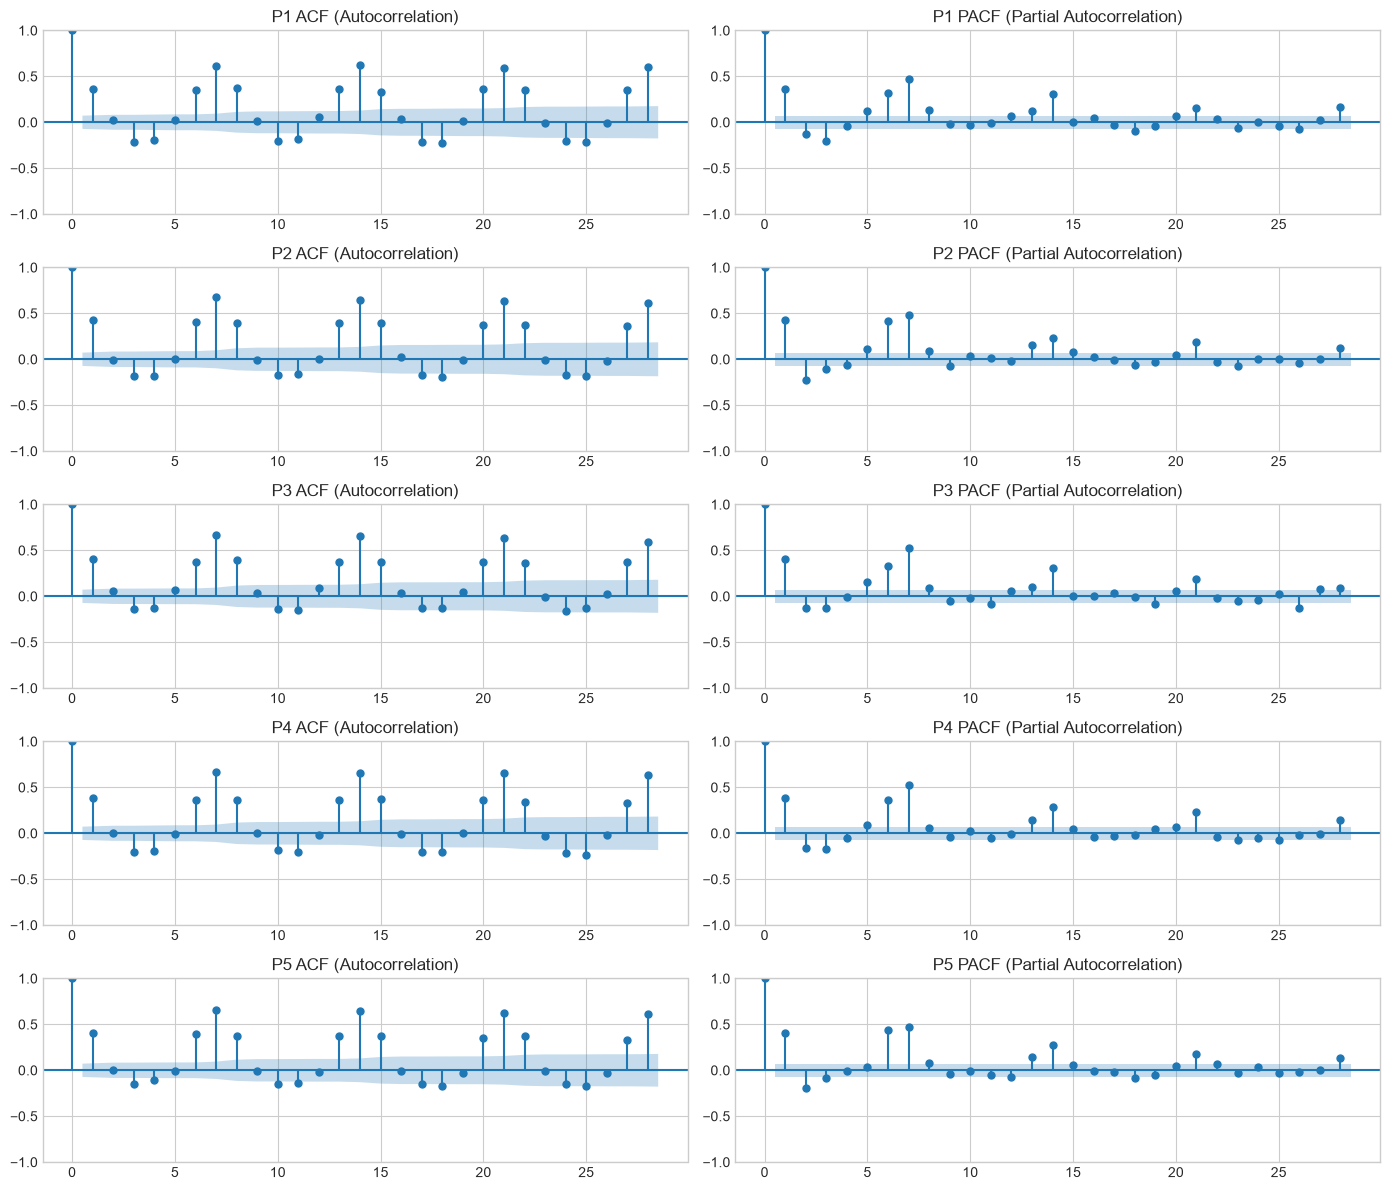

In [4]:
fig, axes = plt.subplots(5, 2, figsize=(14, 12))
for idx, p_id in enumerate(products):
    p_series = df[df['product_id'] == p_id].sort_values('date')['demand']
    plot_acf(p_series, lags=28, ax=axes[idx, 0], title=f"{p_id} ACF (Autocorrelation)")
    plot_pacf(p_series, lags=28, ax=axes[idx, 1], title=f"{p_id} PACF (Partial Autocorrelation)")

plt.tight_layout()
plt.show()

## 4. Cross-Product Demand Correlation Matrix

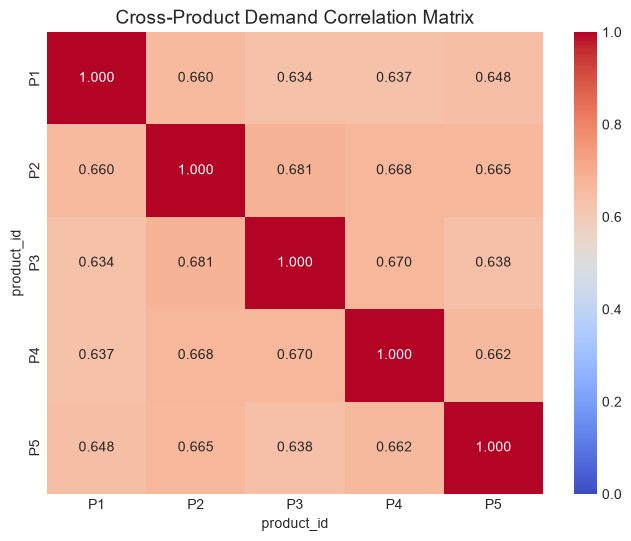

In [5]:
pivot_df = df.pivot(index='date', columns='product_id', values='demand')
corr_matrix = pivot_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt='.3f', ax=ax)
ax.set_title("Cross-Product Demand Correlation Matrix", fontsize=14)
plt.show()

## 5. Feature Engineering Pipeline & Leakage Audit

In [6]:
fe = FeatureEngineer()
df_features = fe.create_features(df)
print("Total features generated:", len(fe.feature_cols))
print("Feature list:", fe.feature_cols)

# Audit anti-leakage property
is_leak_free = fe.audit_leakage(df, "2024-06-01")
print("FeatureEngineer Leakage Audit Passed:", is_leak_free)

Total features generated: 30
Feature list: ['day_of_week', 'month', 'day_of_month', 'day_of_year', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'price_ratio', 'promo_price_interaction', 'demand_lag_1', 'demand_lag_2', 'demand_lag_7', 'demand_lag_14', 'demand_lag_28', 'demand_roll_mean_7', 'demand_roll_std_7', 'demand_roll_min_7', 'demand_roll_max_7', 'demand_roll_mean_14', 'demand_roll_std_14', 'demand_roll_min_14', 'demand_roll_max_14', 'demand_roll_mean_28', 'demand_roll_std_28', 'demand_roll_min_28', 'demand_roll_max_28', 'demand_ewma_a0_1', 'demand_ewma_a0_3']
FeatureEngineer Leakage Audit Passed: True
